In [730]:
# using Pkg; Pkg.add("IJulia")
# using IJulia
# installkernel("Julia 8 Threads", env=Dict("JULIA_NUM_THREADS" => "8"))

# Test out source code

In [731]:
using Pkg 
pars = "RA_intermidiate"
Pkg.activate("../.")
include("../index_model/model.jl")
include("../parameters/$pars.jl")

  Activating project at `~/github/FisheriesInsuranceModel`


ComponentVector{Float64}(b0 = 1.0, g = 0.850441204540233, m̄ = 0.2, m̲ = 0.8931471805599454, r0 = 0.05505466645826072, z = 0.75, b_target = 0.4, b_limit = 0.2, f_target = 0.15870058672439358, T = [0.975 0.5; 0.025 0.5], σ_R = 0.75, μZ = 0.0, μ_P = 18.74677294892589, μ_Ce = 0.0, s̄ = -2.0, k = 0.0, y0 = 0.01, cf = 1.0e-6, cv = 0.0, κ_bankrupt = 0.01, γ = 1.001)

In [732]:
recursive_nt(x) = x
recursive_nt(x::ComponentArray) =
    NamedTuple{propertynames(x)}(map(k -> copy(recursive_nt(getproperty(x, k))), valkeys(x)))

recursive_nt (generic function with 2 methods)

In [733]:
include("index_transitions.jl")

print_index_diagnostics (generic function with 1 method)

In [734]:

# T_mx0 = [0.94/0.95 0.6; (1-0.94/0.95) 0.4]
# T_mx1 = [0.2 0.6; 0.8 0.4] 
# T_x   = [0.95 0.95;  0.05 0.05]

# pars = recursive_nt(p)
# pars = ComponentArray(merge(pars,(T = joint_transition(T_mx0,T_mx1,T_x),)))
# pars.T = pars.T ./ mapslices(sum, pars.T, dims = 1)
set_index_T(p, pr = 0.5, re = 0.5)
pars.cv = 0.2
pars.cf = 0.0
pars.T

LoadError: type String has no field cv

## Set up random variables

In [ ]:
X, Xmc = init_ranom_variables(pars;Nquad = 5)

(ValueFunctionIterations.RandomVariableFunction(var"#Xf#1161"{RandomVariable}(RandomVariable([0.0 0.0 … 0.0 0.0; 18.74677294892589 18.74677294892589 … 18.74677294892589 18.74677294892589; … ; -2.142727510404604 -1.0167196349807006 … 1.0167196349807006 2.142727510404604; 0.285 0.285 … 0.99 0.99], [0.00641672445680078, 0.12658327554319906, 0.30400000000000027, 0.12658327554319906, 0.00641672445680078, 0.0003377223398316203, 0.006662277660168379, 0.01600000000000003, 0.006662277660168379, 0.0003377223398316203  …  0.00022514822655441354, 0.004441518440112252, 0.010666666666666687, 0.004441518440112252, 0.00022514822655441354, 0.00022514822655441354, 0.004441518440112252, 0.010666666666666687, 0.004441518440112252, 0.00022514822655441354]))), MCRandomVariable(7, 4, [0.0 0.0 … 0.0 0.0; 18.74677294892589 18.74677294892589 … 18.74677294892589 18.74677294892589; … ; 0.5442400974759456 0.2768027276899536 … -0.008587696472223957 0.05371209553677009; 0.285 0.585 … 0.97 0.99], [0.57, 0.03000000000

## Check simulation

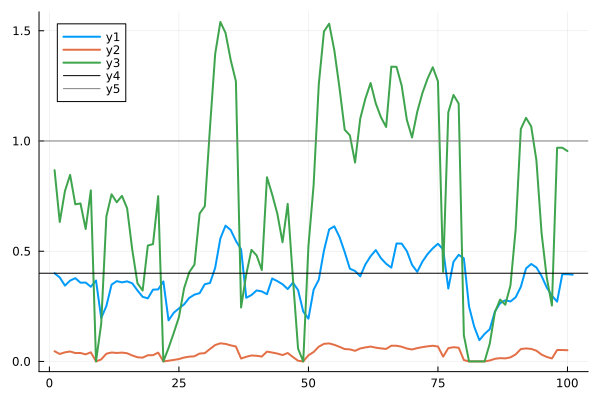

In [ ]:
using Plots
X2, X2mc = init_ranom_variables(pars;Nquad = 30)
states, m, f, h, y = simulate_trajectory(pars,X2,100)
Plots.plot(exp.(states[1,:]), width = 2)
Plots.plot!(h, width = 2)
Plots.plot!(y, width = 2)
Plots.hline!([p.b_target], color = "black")
Plots.hline!([y_target], color = "grey")

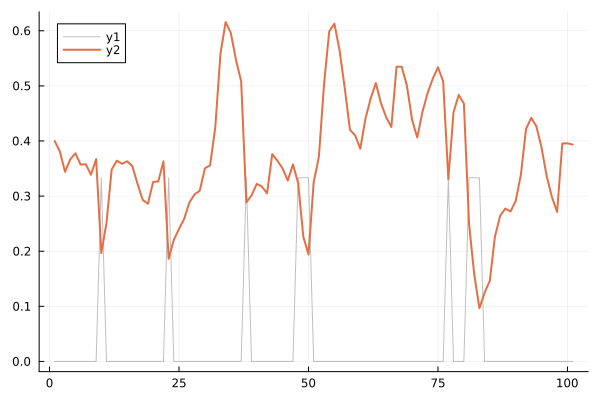

In [ ]:

Plots.plot(0.3333*(states[3,:].-1), width = 1., color = "grey", alpha = 0.5)
Plots.plot!(exp.(states[1,:]), width = 2)

## Check state grid

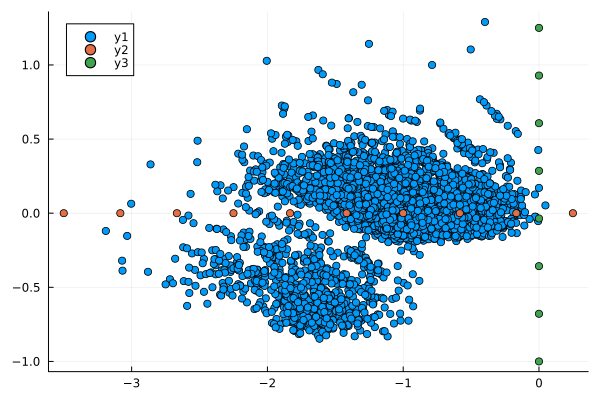

In [ ]:
states, m, f, h, y = simulate_trajectory(pars,X2,10000)
Plots.scatter(states[1,:], states[2,:])
bmax = 0.25; bmin = -3.5; Nb_grid = 10
b_grid = bmin:((bmax-bmin)/(Nb_grid-1)):bmax
Δbmax = 1.25; Δbmin = -1.0; NΔb_grid = 8
Δb_grid = Δbmin:((Δbmax-Δbmin)/(NΔb_grid-1)):Δbmax
Plots.scatter!(b_grid,[0.0])
Plots.scatter!(zeros(length(Δb_grid)),Δb_grid)

## Define remaining state grids

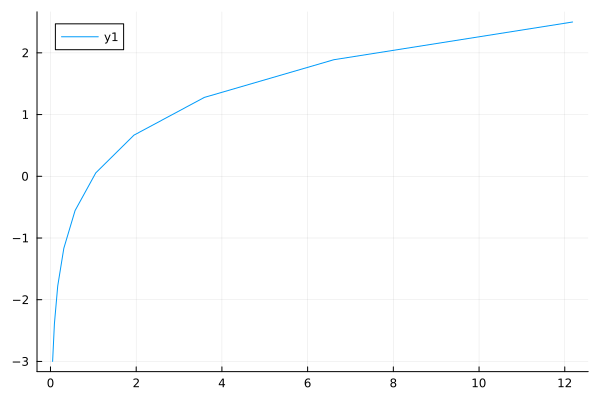

In [ ]:
smax = 2.5; smin = -3.0; Ns_grid = 10
s_grid = smin:((smax-smin)/(Ns_grid-1)):smax
Plots.plot(exp.(s_grid),s_grid)

In [ ]:
state_grid = [s_grid,b_grid,Δb_grid]
nothing

## Define aciton grid 

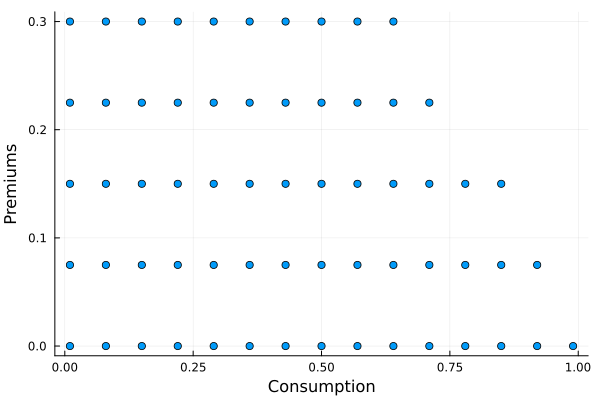

In [ ]:
κmin = 0.01; κmax = 0.99; Nκ = 15
κ_grid = κmin:((κmax-κmin)/(Nκ-1)):κmax
ηmin = 0.0; ηmax=0.3; Nη = 5
η_grid = ηmin:((ηmax-ηmin)/(Nη-1)):ηmax
action_grid = [κ_grid,η_grid]

# plot grid
k=0; u_grid = zeros(2,length(κ_grid)*length(η_grid))
for (i,j) in Iterators.product(1:length(κ_grid),1:length(η_grid))
    k +=1
    u_grid[:,k] = vcat(κ_grid[i],η_grid[j]) 
end
u_grid=u_grid[:,reshape(mapslices(sum,u_grid,dims = 1).<=1,length(κ_grid)*length(η_grid))]
Plots.scatter(u_grid[1,:],u_grid[2,:], xlabel = "Consumption", ylabel= "Premiums", label = "")

# 

## Set up model 

In [ ]:
δ = 0.95
prob = init(action_grid,state_grid,δ,pars,X,index)
estimate_time(prob)

("Estimate (sec)" => 228.31, "One call" => 8.626937866210937e-6, "Number of computations" => 3528560, "actions" => "varaible", "states" => 1616, "random variable samples" => 35, "Estimated iterations" => 60, "Number of threads" => 8)

In [ ]:
X_ = X([0.0,0.0,0.0,0.0,1.0],pars).nodes[:,5]
prob.F([0.0,0.0,0.0,0.0,1.0],[0.1,0.1],X_,pars)

5-element Vector{Float64}:
 1.0
 1.1969481893889715
 0.2085056580021592
 0.2085056580021592
 1.0

In [ ]:
#load_solution(prob,"../results/$pars/sol.jld2")
solve!(prob,maxiter = 40)
nothing

Progress: 100%|█████████████████████████████████████████| Time: 0:02:55


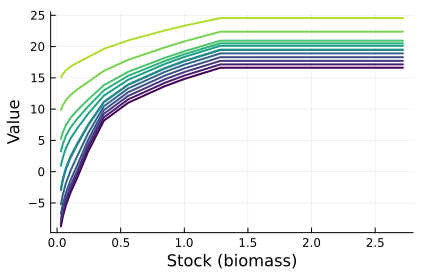

In [ ]:
plot_value_function(prob)

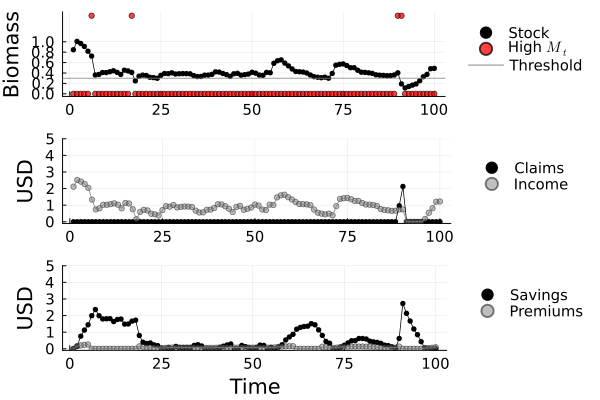

In [743]:
using LaTeXStrings
include("plotting.jl")
x = simulation(prob,El,Xmc,100;with_policy = false, s0 = nothing)
plot_simulation(x,max_USD = 5.0, max_Bt = 1.5)

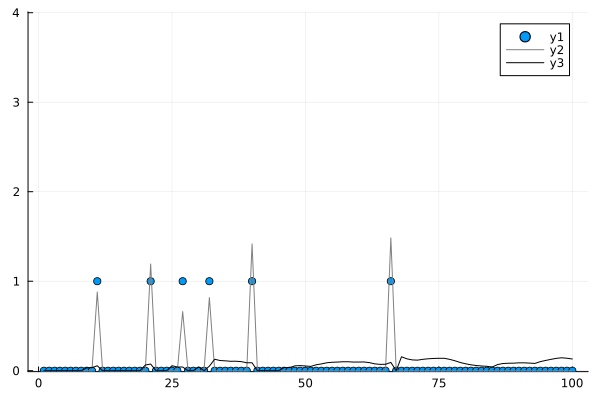

In [740]:
Plots.scatter(x.Zt, ylim = [-0.01,4.01])
Plots.plot!(x.wt, ylim = [-0.01,4.01], color = "grey")
Plots.plot!(x.ηt, ylim = [-0.01,4.01], color = "black")

[0.06250000000000001 0.06250000000000001 0.06250000000000001 0.06250000000000001 0.06250000000000001 0.06250000000000001 0.06250000000000001 0.06250000000000001 0.06250000000000001 0.06250000000000001; 0.06250000000000001 0.06250000000000001 0.06250000000000001 0.06250000000000001 0.06250000000000001 0.06250000000000001 0.06250000000000001 0.06250000000000001 0.06250000000000001 0.06250000000000001; 0.06250000000000001 0.06250000000000001 0.06250000000000001 0.06250000000000001 0.06250000000000001 0.06250000000000001 0.06250000000000001 0.06250000000000001 0.06250000000000001 0.06250000000000001; 0.06250000000000001 0.06250000000000001 0.06250000000000001 0.06250000000000001 0.06250000000000001 0.06250000000000001 0.06250000000000001 0.06250000000000001 0.06250000000000001 0.06250000000000001; 0.06250000000000001 0.06250000000000001 0.06250000000000001 0.06250000000000001 0.06250000000000001 0.06250000000000001 0.06250000000000001 0.06250000000000001 0.06250000000000001 0.0625000000000

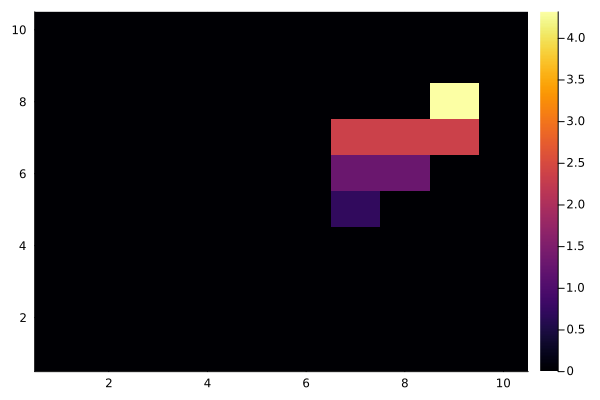

In [729]:
include("analysis.jl")
η_s, η̄_s, state_grid = coverage_levels(prob)
print(η̄_s)
Plots.heatmap(η_s[:,:,5,1]./η̄_s[:,:,5,1])